
# Experiment 1B - Pure RAG with LaBSE Embeddings
### Multilingual Health Question Answering in Low-Resource African Languages

**What changed from Experiment 1:** the embedding model used to build the retrieval index and embed
incoming questions. Experiment 1 used `intfloat/multilingual-e5-large`; this notebook swaps in
`sentence-transformers/LaBSE` (Language-agnostic BERT Sentence Embeddings), keeping everything else
identical - same generator (`facebook/nllb-200-distilled-600M`), same `TOP_K=5`, same prompt structure,
same language-aware per-language indexing.

**Why this specific change.** Experiment 1's per-language results showed a wide spread:

| Language | ROUGE-1 F1 | ROUGE-L F1 |
|---|---|---|
| Swahili  | 0.7573 | 0.7320 |
| English  | 0.5773 | 0.5333 |
| Luganda  | 0.4876 | 0.4625 |
| Akan     | 0.2742 | 0.1638 |
| Amharic  | 0.1605 | 0.1511 |

Akan and Amharic are far behind the other three languages. One plausible cause: `multilingual-e5-large`'s
training mixture, like most multilingual embedding models, is dominated by high-resource languages, and its
exposure to Akan and Luganda specifically (both under-represented even among African-language NLP
resources) may be thin enough that its embedding space doesn't actually place semantically similar Akan
questions close together - which would mean retrieval is returning weak or near-random matches for those
languages, capping everything downstream regardless of generator quality.

LaBSE was trained explicitly for cross-lingual sentence similarity across 109 languages with a training
objective (translation ranking) different from E5's (contrastive retrieval pretraining + supervised
fine-tuning), and has historically shown different - not uniformly better, but different - coverage
patterns across lower-resource languages. Swapping only the embedding model isolates whether the weak
languages are an embedding problem or a generator/prompt problem.

**Hypothesis going in:** if LaBSE meaningfully closes the gap for Akan/Amharic specifically (not just a
uniform shift across all languages), that's evidence the embedding model was the bottleneck for those
languages. If the gap persists or all languages move together, the bottleneck is more likely elsewhere
(generator capacity, prompt design, or genuine data sparsity in the training corpus itself).

**Outputs saved:** `submission_exp1b_labse_embeddings.csv`, `exp1b_metrics.json`, comparison plots.


In [1]:

from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_DIR  = '/content/drive/MyDrive/health_qa_project'
DATA_DIR     = f'{PROJECT_DIR}/data'
ARTIFACT_DIR = f'{PROJECT_DIR}/artifacts'
SUB_DIR      = f'{PROJECT_DIR}/submissions'

EXP1_DIR = f'{ARTIFACT_DIR}/exp1_rag'   # baseline FAISS indexes (E5), reused unless this notebook changes embeddings
EXP_DIR  = f'{ARTIFACT_DIR}/exp1b_labse'

os.makedirs(EXP_DIR, exist_ok=True)
print('Experiment 1B: LaBSE Embeddings (vs Experiment 1 E5-large baseline)')
print('Outputs will be saved under:', EXP_DIR)


Mounted at /content/drive
Experiment 1B: LaBSE Embeddings (vs Experiment 1 E5-large baseline)
Outputs will be saved under: /content/drive/MyDrive/health_qa_project/artifacts/exp1b_labse


In [2]:

!pip install -q sentence-transformers faiss-cpu rouge-score transformers accelerate sentencepiece
print('Dependencies installed')


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 104.3 MB/s eta 0:00:00
Dependencies installed


In [3]:

import re
import json
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import faiss
from sentence_transformers import SentenceTransformer
from rouge_score import rouge_scorer

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEVICE)


Using device: cuda


In [4]:

TRAIN_PATH      = f'{DATA_DIR}/Train.csv'
VAL_PATH        = f'{DATA_DIR}/Val.csv'
TEST_PATH       = f'{DATA_DIR}/Test.csv'
SAMPLE_SUB_PATH = f'{DATA_DIR}/SampleSubmission.csv'

ID_COL       = 'ID'
QUESTION_COL = 'input'
ANSWER_COL   = 'output'
LANG_COL     = 'subset'

SUBSET_TO_LANGUAGE = {
    'Eng': 'English', 'Aka': 'Akan', 'Lug': 'Luganda', 'Swa': 'Swahili', 'Amh': 'Amharic',
}

def subset_to_language_name(subset_code: str) -> str:
    if not subset_code or not isinstance(subset_code, str):
        return 'English'
    return SUBSET_TO_LANGUAGE.get(subset_code.split('_')[0], subset_code)

train             = pd.read_csv(TRAIN_PATH)
test              = pd.read_csv(TEST_PATH)
val               = pd.read_csv(VAL_PATH)
sample_submission = pd.read_csv(SAMPLE_SUB_PATH)

def clean_text(x):
    if pd.isna(x):
        return ''
    return str(x).strip()

train[QUESTION_COL] = train[QUESTION_COL].map(clean_text)
train[ANSWER_COL]   = train[ANSWER_COL].map(clean_text)
val[QUESTION_COL]   = val[QUESTION_COL].map(clean_text)
val[ANSWER_COL]     = val[ANSWER_COL].map(clean_text)
test[QUESTION_COL]  = test[QUESTION_COL].map(clean_text)

train = train[(train[QUESTION_COL] != '') & (train[ANSWER_COL] != '')].reset_index(drop=True)
val   = val[(val[QUESTION_COL] != '') & (val[ANSWER_COL] != '')].reset_index(drop=True)
test  = test[test[QUESTION_COL] != ''].reset_index(drop=True)

train['language'] = train[LANG_COL].map(subset_to_language_name)
val['language']    = val[LANG_COL].map(subset_to_language_name)
test['language']   = test[LANG_COL].map(subset_to_language_name)

print(f'Train shape: {train.shape}, Val shape: {val.shape}, Test shape: {test.shape}')


Train shape: (29814, 5), Val shape: (6686, 5), Test shape: (2618, 4)


In [5]:

class WhitespaceTokenizer:
    '''Whitespace tokeniser - language-agnostic, safe for African scripts.'''
    def tokenize(self, text):
        if text is None:
            return []
        return str(text).strip().split()

_scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], tokenizer=WhitespaceTokenizer(), use_stemmer=False)

def compute_rouge(predictions, references):
    r1_scores, rl_scores = [], []
    for pred, ref in zip(predictions, references):
        score = _scorer.score(str(ref), str(pred))
        r1_scores.append(score['rouge1'].fmeasure)
        rl_scores.append(score['rougeL'].fmeasure)
    return {
        'rouge1_f1': float(np.mean(r1_scores)) if r1_scores else 0.0,
        'rougeL_f1': float(np.mean(rl_scores)) if rl_scores else 0.0,
    }

def compute_rouge_by_language(predictions, references, languages):
    results = {}
    lang_arr = np.array(languages)
    for lang in np.unique(lang_arr):
        mask    = lang_arr == lang
        preds_l = [p for p, m in zip(predictions, mask) if m]
        refs_l  = [r for r, m in zip(references,  mask) if m]
        results[lang] = compute_rouge(preds_l, refs_l)
    return pd.DataFrame(results).T

print('ROUGE scorer ready')


ROUGE scorer ready


In [6]:

# Experiment 1 baseline (full validation set, Variant B: retrieval + zero-shot NLLB-600M generation).
# Hardcoded from the original Experiment 1 run so this notebook's comparison plot works even
# if exp1's metrics json isn't present in this session's Drive mount.
EXP1_BASELINE_BY_LANG = {
    'Akan':     {'rouge1_f1': 0.2742, 'rougeL_f1': 0.1638},
    'Amharic':  {'rouge1_f1': 0.1605, 'rougeL_f1': 0.1511},
    'English':  {'rouge1_f1': 0.5773, 'rougeL_f1': 0.5333},
    'Luganda':  {'rouge1_f1': 0.4876, 'rougeL_f1': 0.4625},
    'Swahili':  {'rouge1_f1': 0.7573, 'rougeL_f1': 0.7320},
}
EXP1_BASELINE_OVERALL = {
    'rouge1_f1': float(np.mean([v['rouge1_f1'] for v in EXP1_BASELINE_BY_LANG.values()])),
    'rougeL_f1': float(np.mean([v['rougeL_f1'] for v in EXP1_BASELINE_BY_LANG.values()])),
}
print('Experiment 1 baseline (unweighted mean across languages):', EXP1_BASELINE_OVERALL)


Experiment 1 baseline (unweighted mean across languages): {'rouge1_f1': 0.45138, 'rougeL_f1': 0.40854}



## Build Language-Aware FAISS Index with LaBSE

Same per-language indexing strategy as Experiment 1 (Section 4 of the project brief), just with a different
embedding model. Note LaBSE does not use the E5-style `"query: "` / `"passage: "` prefix convention - that
convention is specific to E5's training procedure, so we embed raw text here.


In [7]:

EMBED_MODEL_NAME = 'sentence-transformers/LaBSE'
TOP_K = 5   # unchanged from Experiment 1, so this is a clean single-variable comparison

print(f'Loading embedding model: {EMBED_MODEL_NAME} ...')
embed_model = SentenceTransformer(EMBED_MODEL_NAME, device=DEVICE)
print('Embedding model loaded. Max seq length:', embed_model.max_seq_length)


Loading embedding model: sentence-transformers/LaBSE ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/2.02k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

Embedding model loaded. Max seq length: 256


In [8]:

language_indexes = {}
languages = train['language'].unique().tolist()

for lang in languages:
    sub_df = train[train['language'] == lang].reset_index(drop=True)
    # No "passage: " prefix here - LaBSE was not trained with E5's query/passage convention.
    passages = sub_df[QUESTION_COL].tolist()

    print(f'Embedding {len(passages)} training questions for language: {lang} ...')
    embeddings = embed_model.encode(
        passages, batch_size=64, show_progress_bar=True,
        normalize_embeddings=True, convert_to_numpy=True,
    ).astype('float32')

    dim = embeddings.shape[1]
    index = faiss.IndexFlatIP(dim)
    index.add(embeddings)

    language_indexes[lang] = {
        'faiss_index': index,
        'ids':         sub_df[ID_COL].tolist(),
        'questions':   sub_df[QUESTION_COL].tolist(),
        'answers':     sub_df[ANSWER_COL].tolist(),
    }

print('Built LaBSE FAISS indexes:', {k: v['faiss_index'].ntotal for k, v in language_indexes.items()})


Embedding 4455 training questions for language: Akan ...


Batches:   0%|          | 0/70 [00:00<?, ?it/s]

Embedding 1845 training questions for language: Amharic ...


Batches:   0%|          | 0/29 [00:00<?, ?it/s]

Embedding 18061 training questions for language: English ...


...

Embedding 3383 training questions for language: Luganda ...


Batches:   0%|          | 0/53 [00:00<?, ?it/s]

Embedding 2070 training questions for language: Swahili ...


Batches:   0%|          | 0/33 [00:00<?, ?it/s]

Built LaBSE FAISS indexes: {'Akan': 4455, 'Amharic': 1845, 'English': 18061, 'Luganda': 3383, 'Swahili': 2070}


In [9]:

def retrieve_top_k(question: str, language: str, k: int = TOP_K):
    if language not in language_indexes:
        return []
    payload = language_indexes[language]
    query_vec = embed_model.encode([question], normalize_embeddings=True, convert_to_numpy=True).astype('float32')
    k = min(k, payload['faiss_index'].ntotal)
    scores, idxs = payload['faiss_index'].search(query_vec, k)
    return [
        {'question': payload['questions'][idx], 'answer': payload['answers'][idx], 'score': float(score)}
        for score, idx in zip(scores[0], idxs[0])
    ]

sample_row = val.iloc[0]
sample_results = retrieve_top_k(sample_row[QUESTION_COL], sample_row['language'], k=3)
print(f'Sample retrieval ({sample_row["language"]}):')
for r in sample_results:
    print(f'  score={r["score"]:.3f}: {r["question"][:90]}...')


Sample retrieval (Akan):
  score=0.943: Ɛbɛ yɛ sɛn na amammerɛ abakɔsɛm betumi aka wɔ a wɔresi sɔ no brabɔ ho adeɛ anaa suban, gyi...
  score=0.941: Nneɛma bɛn na ɛwɔ hɔ a ɛbɛboa mmabun ma wɔafa ɔkwan a wɔfa so nya adwenemyareɛ ho dwumadie...
  score=0.938: Ɛbɛyɛ dɛn na mmabun atumi asua sɛnea wɔbɛkamfo sikasɛm ho nhyehyɛe ne tebea horow a ɛfata ...


## Variant A — Pure Retrieval-Only (Nearest-Neighbour Answer Copying)

The simplest possible RAG variant: no generation at all. For each test/validation question,
retrieve the single most similar training question (using LaBSE embeddings + FAISS) and return
**its answer directly**. This is the ceiling/floor of "the training set already contains
something close enough to copy."

This variant uses the same `language_indexes` already built above with LaBSE — no additional
model is needed.


In [10]:
def predict_retrieval_only(df, question_col=QUESTION_COL, lang_col='language'):
    """
    Variant A: Pure retrieval-only (nearest-neighbour answer copying).
    Returns the answer of the top-1 most similar training question.
    """
    predictions = []
    retrieved_scores = []
    for _, row in df.iterrows():
        top1 = retrieve_top_k(row[question_col], row[lang_col], k=1)
        if top1:
            predictions.append(top1[0]['answer'])
            retrieved_scores.append(top1[0]['score'])
        else:
            predictions.append('')
            retrieved_scores.append(0.0)
    return predictions, retrieved_scores

print('Running Variant A (retrieval-only) prediction on validation set ...')
val_preds_variant_a, val_scores_variant_a = predict_retrieval_only(val)

metrics_variant_a = compute_rouge(val_preds_variant_a, val[ANSWER_COL].tolist())
print('Variant A (retrieval-only) validation ROUGE:', metrics_variant_a)


Running Variant A (retrieval-only) prediction on validation set ...
Variant A (retrieval-only) validation ROUGE: {'rouge1_f1': 0.45699283113023664, 'rougeL_f1': 0.40912110283337877}


,rouge1_f1,rougeL_f1
Akan,0.2558,0.1535
Amharic,0.1624,0.1533
English,0.5443,0.5010
Luganda,0.3435,0.3136
Swahili,0.7066,0.6786


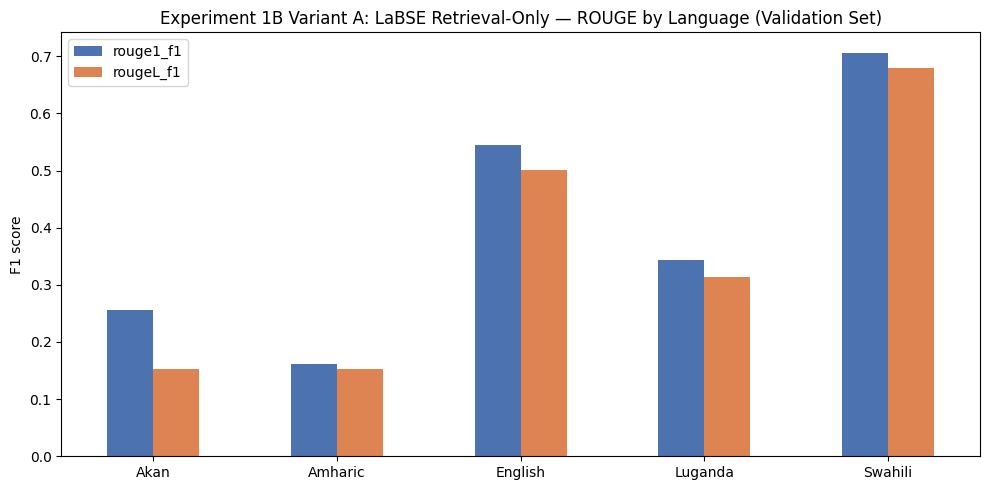

In [11]:
# Per-language breakdown for Variant A
rouge_by_lang_variant_a = compute_rouge_by_language(
    val_preds_variant_a, val[ANSWER_COL].tolist(), val['language'].tolist()
)
display(rouge_by_lang_variant_a.round(4))

rouge_by_lang_variant_a[['rouge1_f1', 'rougeL_f1']].plot(
    kind='bar', figsize=(10, 5), color=['#4C72B0', '#DD8452']
)
plt.title('Experiment 1B Variant A: LaBSE Retrieval-Only — ROUGE by Language (Validation Set)')
plt.ylabel('F1 score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{EXP_DIR}/exp1b_variantA_rouge_by_language.png', dpi=150)
plt.show()


In [ ]:

from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

GEN_MODEL_NAME = 'facebook/nllb-200-distilled-600M'   # unchanged from Experiment 1
MAX_NEW_TOKENS = 128

gen_tokenizer = AutoTokenizer.from_pretrained(GEN_MODEL_NAME)
gen_model     = AutoModelForSeq2SeqLM.from_pretrained(GEN_MODEL_NAME).to(DEVICE)
gen_model.eval()
print('Generation model loaded (same as Experiment 1).')


config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/3.55k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Generation model loaded (same as Experiment 1).


In [ ]:

def build_rag_prompt(question, language, retrieved_examples):
    lines = ['You are a multilingual health assistant.', f'Answer only in {language}.', '']
    for i, ex in enumerate(retrieved_examples, start=1):
        lines += [f'Reference Example {i}', 'Question:', ex['question'], 'Answer:', ex['answer'], '']
    lines += ['Current Question:', question, '', 'Answer:']
    return '\n'.join(lines)

def predict_retrieval_plus_generation(df, batch_size=8):
    prompts = []
    for _, row in df.iterrows():
        retrieved = retrieve_top_k(row[QUESTION_COL], row['language'], k=TOP_K)
        prompts.append(build_rag_prompt(row[QUESTION_COL], row['language'], retrieved))

    predictions = []
    for start in range(0, len(prompts), batch_size):
        batch_prompts = prompts[start:start + batch_size]
        inputs = gen_tokenizer(batch_prompts, return_tensors='pt', padding=True, truncation=True, max_length=1024).to(DEVICE)
        with torch.no_grad():
            output_ids = gen_model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, num_beams=2)
        predictions.extend(gen_tokenizer.batch_decode(output_ids, skip_special_tokens=True))
        if start % (batch_size * 10) == 0:
            print(f'  Generated {start + len(batch_prompts)} / {len(prompts)}')
    return predictions

print('Running retrieval (LaBSE) + generation (NLLB) on the FULL validation set ...')
val_preds_this_exp = predict_retrieval_plus_generation(val)


Running retrieval (LaBSE) + generation (NLLB) on the FULL validation set ...


[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Generated 8 / 6686


[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

  Generated 88 / 6686


...

  Generated 328 / 6686


[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

  Generated 408 / 6686


[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

KeyboardInterrupt: 

## Variant B — Retrieval (LaBSE) + Zero-Shot Generation (NLLB-600M)

Feed the top-K retrieved Q/A pairs (LaBSE retrieval) as in-context examples into NLLB-600M
and let it generate the final answer. This tests whether light synthesis over retrieved
examples beats blindly copying the single nearest neighbour (Variant A above).


In [ ]:
print('Running Variant B (LaBSE retrieval + NLLB generation) on the FULL validation set ...')
val_preds_variant_b = predict_retrieval_plus_generation(val)
print(f'Generated {len(val_preds_variant_b)} validation predictions.')


## Compare Variant A (Retrieval-Only) vs Variant B (Retrieval + Generation)

Both variants use LaBSE embeddings — the only difference is whether NLLB-600M generation
is applied on top. This comparison shows whether generation adds value for LaBSE-retrieved
context.


In [ ]:
# Per-language breakdown for Variant B
rouge_by_lang_variant_b = compute_rouge_by_language(
    val_preds_variant_b, val[ANSWER_COL].tolist(), val['language'].tolist()
)
print('=== Variant B (Retrieval + Generation) — ROUGE by Language ===')
display(rouge_by_lang_variant_b.round(4))

metrics_variant_b = compute_rouge(val_preds_variant_b, val[ANSWER_COL].tolist())
print('Variant B overall validation ROUGE:', metrics_variant_b)

# Side-by-side summary
languages_order = ['Akan', 'Amharic', 'English', 'Luganda', 'Swahili']
compare_df = pd.DataFrame({
    'Variant A (Retrieval-Only) ROUGE-L': [
        rouge_by_lang_variant_a.loc[l, 'rougeL_f1'] if l in rouge_by_lang_variant_a.index else float('nan')
        for l in languages_order
    ],
    'Variant B (Retrieval+Gen) ROUGE-L': [
        rouge_by_lang_variant_b.loc[l, 'rougeL_f1'] if l in rouge_by_lang_variant_b.index else float('nan')
        for l in languages_order
    ],
    'Exp1 Baseline (E5) ROUGE-L': [EXP1_BASELINE_BY_LANG[l]['rougeL_f1'] for l in languages_order],
}, index=languages_order)
display(compare_df.round(4))

compare_df.plot(kind='bar', figsize=(12, 6), color=['#4C72B0', '#C44E52', '#999999'])
plt.title('Exp 1B: Variant A vs Variant B vs Exp1 Baseline — ROUGE-L by Language')
plt.ylabel('ROUGE-L F1')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{EXP_DIR}/exp1b_variantA_vs_variantB.png', dpi=150)
plt.show()


In [14]:

def make_submission(ids, predictions, output_path):
    clean_preds = [re.sub(r'<extra_id_\d+>', '', str(p)).strip() for p in predictions]

    sub = pd.DataFrame()
    sub['ID']         = ids
    sub['TargetRLF1'] = clean_preds
    sub['TargetR1F1'] = clean_preds
    sub['TargetLLM']  = clean_preds
    sub = sub[['ID', 'TargetRLF1', 'TargetR1F1', 'TargetLLM']]

    required_cols = ['ID', 'TargetRLF1', 'TargetR1F1', 'TargetLLM']
    assert list(sub.columns) == required_cols
    assert len(sub) == len(test), f'Row count mismatch: {len(sub)} vs {len(test)}'
    assert sub[['TargetRLF1', 'TargetR1F1', 'TargetLLM']].notna().all().all()
    assert (sub['TargetRLF1'] == sub['TargetR1F1']).all()
    assert (sub['TargetRLF1'] == sub['TargetLLM']).all()

    sub.to_csv(output_path, index=False, encoding='utf-8')
    print(f'Submission saved to: {output_path}')
    print(f'  Shape: {sub.shape}')
    display(sub.head(3))
    return sub


## Variant A — Generate Test Predictions and Submission File

Using the LaBSE retrieval-only approach (no generation) on the test set.


In [12]:
print('Generating Variant A test predictions (LaBSE retrieval-only) ...')
test_preds_variant_a, test_scores_variant_a = predict_retrieval_only(test)
print(f'Generated {len(test_preds_variant_a)} test predictions.')


Generating Variant A test predictions (LaBSE retrieval-only) ...
Generated 2618 test predictions.


In [15]:
sub_variant_a = make_submission(
    test[ID_COL].values,
    test_preds_variant_a,
    f'{SUB_DIR}/submission_exp1b_labse_variantA_retrieval_only.csv'
)


Submission saved to: /content/drive/MyDrive/health_qa_project/submissions/submission_exp1b_labse_variantA_retrieval_only.csv
  Shape: (2618, 4)


,ID,TargetRLF1,TargetR1F1,TargetLLM
0,ID_TS_Aka_Gha_A3B1799D,GBV betumi asi wɔ akwan horow pii so. Nsɛnkyer...,GBV betumi asi wɔ akwan horow pii so. Nsɛnkyer...,GBV betumi asi wɔ akwan horow pii so. Nsɛnkyer...
1,ID_TS_Aka_Gha_1C80317F,Amammerɛ ne nyamesom mu gyidi betumi akyerɛ su...,Amammerɛ ne nyamesom mu gyidi betumi akyerɛ su...,Amammerɛ ne nyamesom mu gyidi betumi akyerɛ su...
2,ID_TS_Aka_Gha_06671AD1,Nnipa a wɔn ho nka ho tee yɛ biribi. Ɛsi basab...,Nnipa a wɔn ho nka ho tee yɛ biribi. Ɛsi basab...,Nnipa a wɔn ho nka ho tee yɛ biribi. Ɛsi basab...


In [ ]:
results_variant_a = {
    'experiment': 'Experiment 1B Variant A: Pure RAG (LaBSE) - Retrieval-Only',
    'variant': 'A - retrieval_only',
    'embed_model': EMBED_MODEL_NAME,
    'gen_model': None,
    'top_k': 1,
    'full_validation_metrics': metrics_variant_a,
    'rouge_by_language': rouge_by_lang_variant_a.round(4).to_dict(orient='index'),
}

with open(f'{EXP_DIR}/exp1b_variantA_metrics.json', 'w') as f:
    json.dump(results_variant_a, f, indent=2)

print('Saved Variant A metrics to:', f'{EXP_DIR}/exp1b_variantA_metrics.json')
print(json.dumps({k: v for k, v in results_variant_a.items() if k != 'rouge_by_language'}, indent=2))


## Variant B — Generate Test Predictions and Submission File

Using LaBSE retrieval + NLLB-600M zero-shot generation on the test set.


In [ ]:
print('Generating Variant B test predictions (LaBSE retrieval + NLLB generation) ...')
test_preds_variant_b = predict_retrieval_plus_generation(test)
print(f'Generated {len(test_preds_variant_b)} test predictions.')


In [ ]:
sub_variant_b = make_submission(
    test[ID_COL].values,
    test_preds_variant_b,
    f'{SUB_DIR}/submission_exp1b_labse_variantB_retrieval_plus_gen.csv'
)


In [ ]:
results_variant_b = {
    'experiment': 'Experiment 1B Variant B: Pure RAG (LaBSE) - Retrieval + NLLB Generation',
    'variant': 'B - retrieval_plus_generation',
    'embed_model': EMBED_MODEL_NAME,
    'gen_model': GEN_MODEL_NAME,
    'top_k': TOP_K,
    'full_validation_metrics': metrics_variant_b,
    'rouge_by_language': rouge_by_lang_variant_b.round(4).to_dict(orient='index'),
    'baseline_comparison': {
        'baseline_overall': EXP1_BASELINE_OVERALL,
        'improvement_rougeL': metrics_variant_b['rougeL_f1'] - EXP1_BASELINE_OVERALL['rougeL_f1'],
    },
}
results_variant_b.update({'embed_model': EMBED_MODEL_NAME, 'gen_model': GEN_MODEL_NAME, 'top_k': TOP_K})

with open(f'{EXP_DIR}/exp1b_variantB_metrics.json', 'w') as f:
    json.dump(results_variant_b, f, indent=2)

print('Saved Variant B metrics to:', f'{EXP_DIR}/exp1b_variantB_metrics.json')
print(json.dumps({k: v for k, v in results_variant_b.items() if k != 'rouge_by_language'}, indent=2))


## Summary: Variant A vs Variant B

Both submission files have been generated:
- `submission_exp1b_labse_variantA_retrieval_only.csv` — pure nearest-neighbour answer copying
- `submission_exp1b_labse_variantB_retrieval_plus_gen.csv` — LaBSE retrieval + NLLB-600M generation

Submit both to compare leaderboard scores. The per-language breakdown above shows which
variant and which languages benefited most from LaBSE embeddings vs the E5-large baseline.



## Interpretation Notes for the Report

Write up this experiment by directly addressing the hypothesis stated in the introduction:

- If Akan/Amharic ROUGE-L improved noticeably more than English/Swahili/Luganda did, that's evidence the
  E5 embedding model specifically under-served those two languages, and LaBSE (or another embedding model)
  is worth carrying forward into later experiments.
- If all five languages moved roughly in proportion to each other (or didn't move much at all), the
  embedding model probably was not the binding constraint - look at Experiment 1D (generator model) and
  1E (prompt engineering) for where the bottleneck more likely sits.
- Either outcome is a valid, reportable finding - the value of this experiment is in *ruling something in
  or out*, not in needing to show improvement.
